In [5]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [7]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
INTERIMDIR = CONFIGS['filepaths']['interim']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
YEARS      = np.arange(2000,2018)

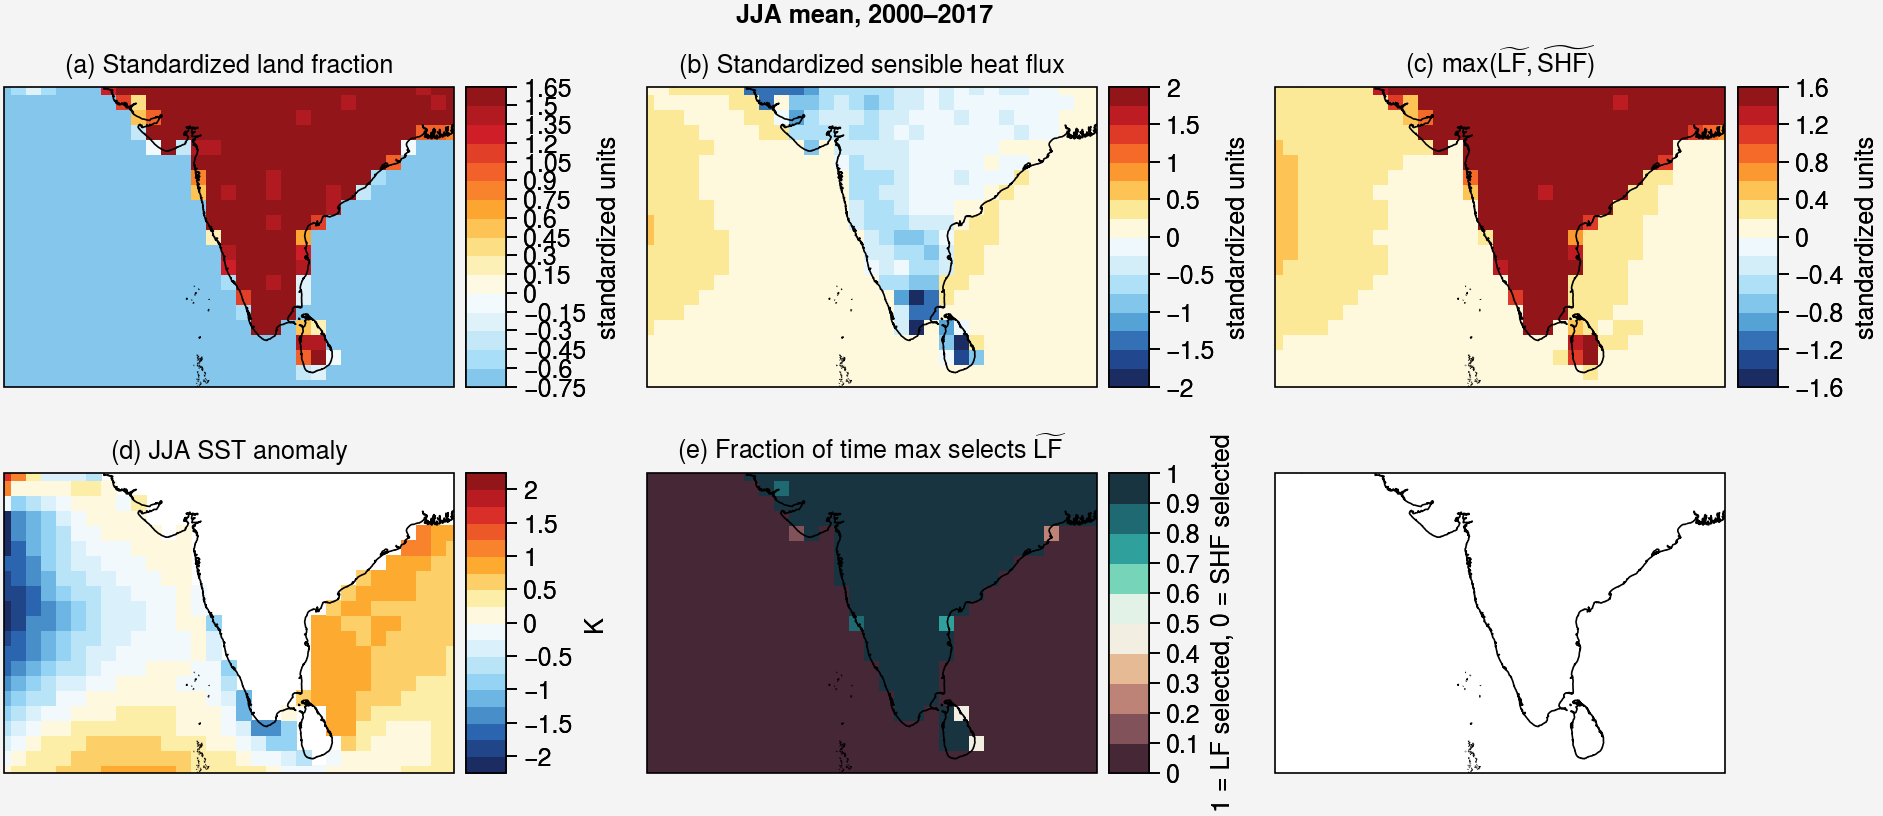

In [13]:



def jja_3hourly_mean(da, years=YEARS):
    """
    Convert hourly data to 3-hourly means if needed, then return
    JJA mean over selected years.

    If data are already 3-hourly, resampling is still safe.
    """
    if "time" not in da.dims:
        return da

    da_3h = da.resample(time="3h").mean()

    da_jja = da_3h.where(
        da_3h.time.dt.year.isin(years)
        & da_3h.time.dt.month.isin(JJA_MONTHS),
        drop=True,
    )

    return da_jja.mean("time", skipna=True)


# -------------------------
# Load normalized LF and SHF
# -------------------------
lf_list = []
shf_list = []

for split in ["train", "valid"]:
    path = os.path.join(SPLITSDIR, f"norm_{split}.h5")

    with xr.open_dataset(path, engine="h5netcdf") as ds:
        lf_list.append(ds["lf"].load())
        shf_list.append(ds["shf"].load())

lf_z = xr.concat(lf_list, dim="time") if "time" in lf_list[0].dims else lf_list[0]
shf_z = xr.concat(shf_list, dim="time")

# JJA means for 2000–2017
lf_z_mean = jja_3hourly_mean(lf_z)
shf_z_mean = jja_3hourly_mean(shf_z)

# For max(lf, shf), compute max at each timestep first, then average.
# If LF is static, broadcast it to SHF time.
if "time" not in lf_z.dims:
    lf_for_max = lf_z.expand_dims(time=shf_z.time).broadcast_like(shf_z)
else:
    lf_for_max = lf_z.broadcast_like(shf_z)

max_z = xr.apply_ufunc(np.maximum, lf_for_max, shf_z)
max_z_mean = jja_3hourly_mean(max_z)

# ---------------------------------
# Which variable wins the max()?
# ---------------------------------
# 1 = LF selected
# 0 = SHF selected

selector = xr.where(lf_for_max >= shf_z, 1.0, 0.0)

# JJA fraction of time LF dominates
selector_mean = jja_3hourly_mean(selector)


# -------------------------
# Load SST
# -------------------------
sst_path = os.path.join(INTERIMDIR, "sst.nc")  # change to "stt.nc" if that is the real filename

with xr.open_dataset(sst_path) as ds_sst:
    # adjust variable name if needed
    if "sst" in ds_sst:
        sst = ds_sst["sst"].load()
    elif "SST" in ds_sst:
        sst = ds_sst["SST"].load()
    else:
        raise KeyError(f"Could not find SST variable. Available vars: {list(ds_sst.data_vars)}")

sst_jja_mean = jja_3hourly_mean(sst)

# optional: mask land if SST has NaNs over land already
sst_anom = sst_jja_mean - sst_jja_mean.mean(skipna=True)


# -------------------------
# Plot
# -------------------------
# fig, axs = pplt.subplots(
#     nrows=2,
#     ncols=2,
#     proj="cyl",
#     figwidth=6.5,
#     share=False,
# )

# axs.format(
#     coast=True,
#     borders=False,
#     latlim=LATRANGE,
#     lonlim=LONRANGE,
#     latlines=5,
#     lonlines=5,
#     grid=False,
# )

# # Panel (a): standardized LF
# m0 = axs[0].pcolormesh(
#     lf_z_mean.lon,
#     lf_z_mean.lat,
#     lf_z_mean,
#     cmap="ColdHot",
#     levels=21,
# )
# axs[0].format(title="(a) Standardized land fraction")
# fig.colorbar(m0, ax=axs[0], loc="b", label="standardized units")

# # Panel (b): standardized SHF
# shf_lim = np.nanmax(np.abs(shf_z_mean.values))
# m1 = axs[1].pcolormesh(
#     shf_z_mean.lon,
#     shf_z_mean.lat,
#     shf_z_mean,
#     cmap="ColdHot",
#     vmin=-shf_lim,
#     vmax=shf_lim,
#     levels=21,
# )
# axs[1].format(title="(b) Standardized sensible heat flux")
# fig.colorbar(m1, ax=axs[1], loc="b", label="standardized units")

# # Panel (c): mean max(LF_z, SHF_z)
# max_lim = np.nanmax(np.abs(max_z_mean.values))
# m2 = axs[2].pcolormesh(
#     max_z_mean.lon,
#     max_z_mean.lat,
#     max_z_mean,
#     cmap="ColdHot",
#     vmin=-max_lim,
#     vmax=max_lim,
#     levels=21,
# )
# axs[2].format(title=r"(c) max$(\widetilde{LF}, \widetilde{SHF})$")
# fig.colorbar(m2, ax=axs[2], loc="b", label="standardized units")

# # # Panel (d): SST JJA mean
# # m3 = axs[3].pcolormesh(
# #     sst_jja_mean.lon,
# #     sst_jja_mean.lat,
# #     sst_jja_mean,
# #     cmap="Thermal",
# #     levels=21,
# # )
# # axs[3].format(title="(d) SST")
# # fig.colorbar(m3, ax=axs[3], loc="b", label="SST")

# sst_lim = np.nanmax(np.abs(sst_anom.values))

# m3 = axs[3].pcolormesh(
#     sst_anom.lon,
#     sst_anom.lat,
#     sst_anom,
#     cmap="ColdHot",
#     vmin=-sst_lim,
#     vmax=sst_lim,
#     levels=21,
# )
# axs[3].format(title="(d) JJA SST anomaly")
# fig.colorbar(m3, ax=axs[3], loc="b", label="K")

# fig.format(suptitle="JJA mean, 2000–2017")

# pplt.show()
# fig.save("../figs/fig_lf_shf_max_sst_jja_2000_2017.jpg")

fig, axs = pplt.subplots(
    nrows=2,
    ncols=3,
    proj="cyl",
    figwidth=9.5,
    share=False,
)

axs.format(
    coast=True,
    borders=False,
    latlim=LATRANGE,
    lonlim=LONRANGE,
    latlines=5,
    lonlines=5,
    grid=False,
)

# Panel (a): standardized LF
m0 = axs[0].pcolormesh(
    lf_z_mean.lon,
    lf_z_mean.lat,
    lf_z_mean,
    cmap="ColdHot",
    levels=21,
)
axs[0].format(title="(a) Standardized land fraction")
fig.colorbar(m0, ax=axs[0], loc="b", label="standardized units")

# Panel (b): standardized SHF
shf_lim = np.nanmax(np.abs(shf_z_mean.values))
m1 = axs[1].pcolormesh(
    shf_z_mean.lon,
    shf_z_mean.lat,
    shf_z_mean,
    cmap="ColdHot",
    vmin=-shf_lim,
    vmax=shf_lim,
    levels=21,
)
axs[1].format(title="(b) Standardized sensible heat flux")
fig.colorbar(m1, ax=axs[1], loc="b", label="standardized units")

# Panel (c): mean max(LF_z, SHF_z)
max_lim = np.nanmax(np.abs(max_z_mean.values))
m2 = axs[2].pcolormesh(
    max_z_mean.lon,
    max_z_mean.lat,
    max_z_mean,
    cmap="ColdHot",
    vmin=-max_lim,
    vmax=max_lim,
    levels=21,
)
axs[2].format(title=r"(c) max$(\widetilde{LF}, \widetilde{SHF})$")
fig.colorbar(m2, ax=axs[2], loc="b", label="standardized units")

# # Panel (d): SST JJA mean
# m3 = axs[3].pcolormesh(
#     sst_jja_mean.lon,
#     sst_jja_mean.lat,
#     sst_jja_mean,
#     cmap="Thermal",
#     levels=21,
# )
# axs[3].format(title="(d) SST")
# fig.colorbar(m3, ax=axs[3], loc="b", label="SST")

sst_lim = np.nanmax(np.abs(sst_anom.values))

m3 = axs[3].pcolormesh(
    sst_anom.lon,
    sst_anom.lat,
    sst_anom,
    cmap="ColdHot",
    vmin=-sst_lim,
    vmax=sst_lim,
    levels=21,
)
axs[3].format(title="(d) JJA SST anomaly")
fig.colorbar(m3, ax=axs[3], loc="b", label="K")

# Panel (e): selector map
m4 = axs[4].pcolormesh(
    selector_mean.lon,
    selector_mean.lat,
    selector_mean,
    cmap="DryWet",
    vmin=0,
    vmax=1,
    levels=11,
)

axs[4].format(
    title=r"(e) Fraction of time max selects $\widetilde{LF}$"
)

fig.colorbar(
    m4,
    ax=axs[4],
    loc="b",
    label="1 = LF selected, 0 = SHF selected",
)

fig.format(suptitle="JJA mean, 2000–2017")

pplt.show()

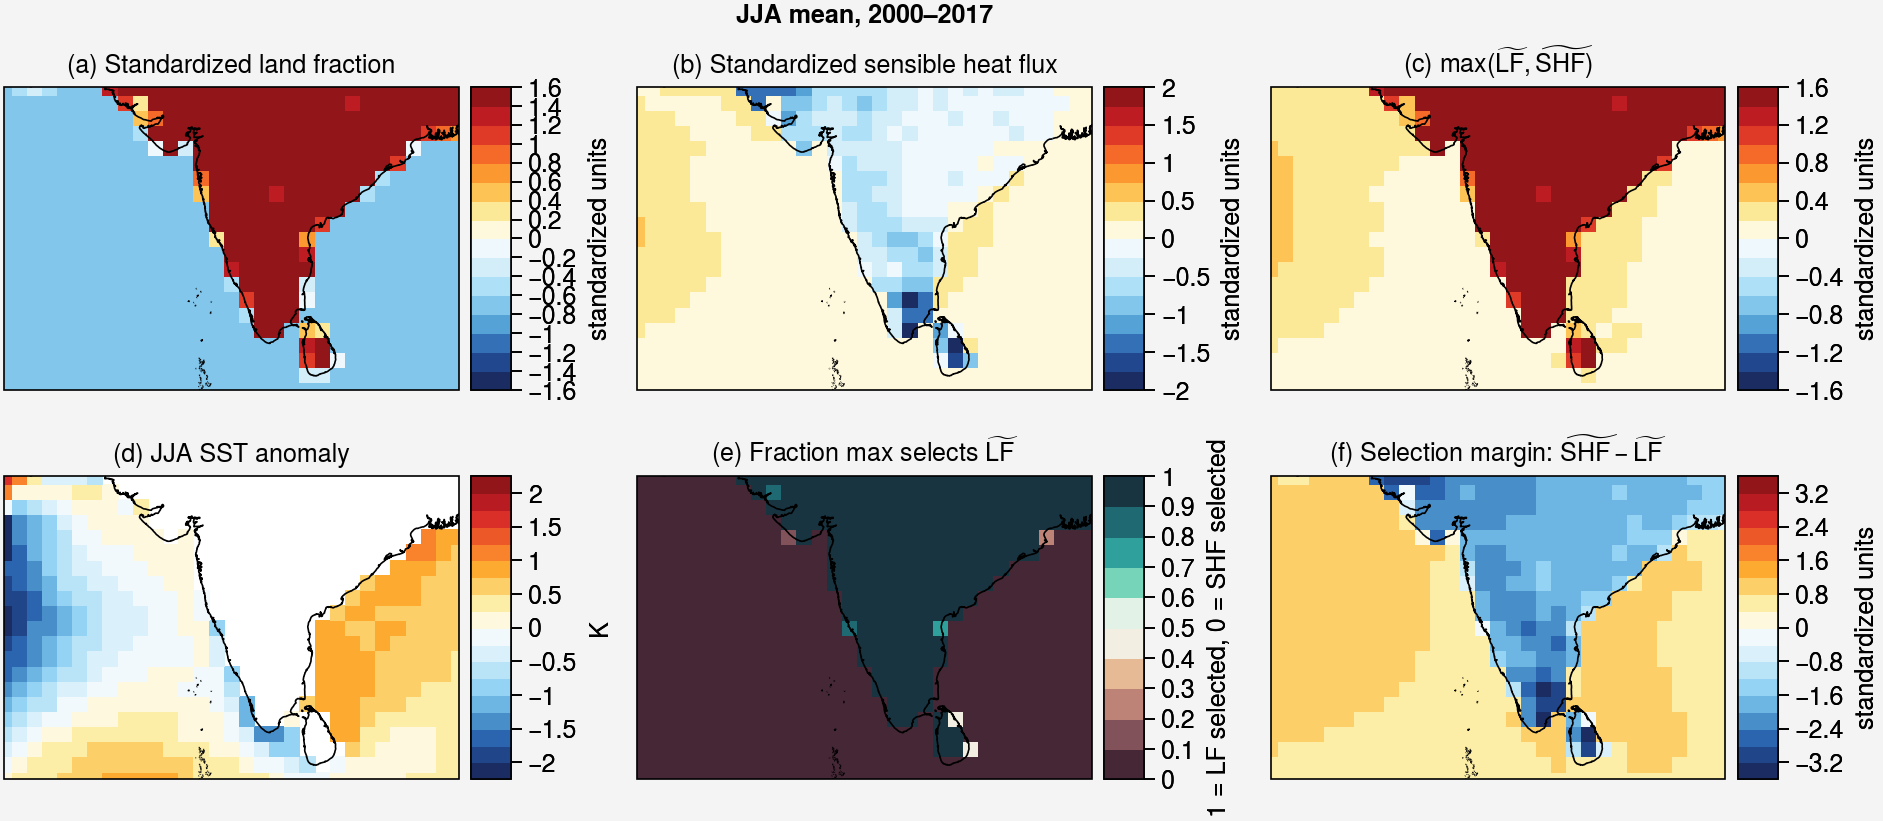

In [17]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt

warnings.filterwarnings("ignore")

pplt.rc.update({
    "savefig.dpi": 900,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "tick.minor": False,
    "font.size": 9,
    "label.size": 9,
    "tick.labelsize": 9,
    "title.size": 9,
    "abc.size": 9,
    "legend.fontsize": 9,
    "suptitle.size": 9,
    "leftlabelsize": 9,
    "toplabelsize": 9,
    "leftlabel.weight": "normal",
    "toplabel.weight": "normal",
    "reso": "xx-hi",
})

with open("../scripts/configs.json", "r", encoding="utf-8") as f:
    CONFIGS = json.load(f)

SPLITSDIR  = CONFIGS["filepaths"]["splits"]
INTERIMDIR = CONFIGS["filepaths"]["interim"]
LATRANGE   = CONFIGS["domain"]["latrange"]
LONRANGE   = CONFIGS["domain"]["lonrange"]

YEARS = np.arange(2000, 2018)
JJA_MONTHS = [6, 7, 8]


def get_var(ds, possible_names):
    for name in possible_names:
        if name in ds:
            return ds[name]
    raise KeyError(
        f"Could not find any of {possible_names}. "
        f"Available vars: {list(ds.data_vars)}"
    )


def jja_3hourly_mean(da, years=YEARS):
    """
    Convert hourly data to 3-hourly means, subset to JJA during selected years,
    and average over time.
    """
    if "time" not in da.dims:
        return da

    da_3h = da.resample(time="3h").mean()

    da_jja = da_3h.where(
        da_3h.time.dt.year.isin(years)
        & da_3h.time.dt.month.isin(JJA_MONTHS),
        drop=True,
    )

    return da_jja.mean("time", skipna=True)


# ============================================================
# 1. Load standardized LF and SHF from train + valid splits
# ============================================================

lf_list = []
shf_list = []

for split in ["train", "valid"]:
    path = os.path.join(SPLITSDIR, f"norm_{split}.h5")

    with xr.open_dataset(path, engine="h5netcdf") as ds:
        lf_list.append(ds["lf"].load())
        shf_list.append(ds["shf"].load())

# LF may be static or time-varying depending on preprocessing
if "time" in lf_list[0].dims:
    lf_z = xr.concat(lf_list, dim="time")
else:
    lf_z = lf_list[0]

shf_z = xr.concat(shf_list, dim="time")

lf_z_mean = jja_3hourly_mean(lf_z)
shf_z_mean = jja_3hourly_mean(shf_z)


# ============================================================
# 2. Compute max(LF, SHF), selector, and selection margin
# ============================================================

# Broadcast LF to SHF time dimension if LF is static
if "time" not in lf_z.dims:
    lf_for_max = lf_z.expand_dims(time=shf_z.time).broadcast_like(shf_z)
else:
    lf_for_max = lf_z.broadcast_like(shf_z)

# The discovered SR-HI surface term
max_z = xr.apply_ufunc(np.maximum, lf_for_max, shf_z)
max_z_mean = jja_3hourly_mean(max_z)

# 1 = LF selected by max()
# 0 = SHF selected by max()
selector = xr.where(lf_for_max >= shf_z, 1.0, 0.0)
selector_mean = jja_3hourly_mean(selector)

# Positive = SHF exceeds LF, so SHF wins
# Negative = LF exceeds SHF, so LF wins
selection_margin = jja_3hourly_mean(shf_z - lf_for_max)


# ============================================================
# 3. Load SST and compute JJA SST anomaly
# ============================================================

sst_path = os.path.join(INTERIMDIR, "sst.nc")

with xr.open_dataset(sst_path) as ds_sst:
    sst = get_var(ds_sst, ["sst", "SST", "stt", "STT"]).load()

sst_jja_mean = jja_3hourly_mean(sst)

# Spatial anomaly relative to available ocean/domain mean
sst_anom = sst_jja_mean - sst_jja_mean.mean(skipna=True)


# ============================================================
# 4. Plot 2 x 3 figure
# ============================================================

fig, axs = pplt.subplots(
    nrows=2,
    ncols=3,
    proj="cyl",
    figwidth=9.5,
    share=False,
)

axs.format(
    coast=True,
    borders=False,
    latlim=LATRANGE,
    lonlim=LONRANGE,
    latlines=5,
    lonlines=5,
    grid=False,
)


# -------------------------
# (a) Standardized LF
# -------------------------

lf_lim = np.nanmax(np.abs(lf_z_mean.values))

m0 = axs[0].pcolormesh(
    lf_z_mean.lon,
    lf_z_mean.lat,
    lf_z_mean,
    cmap="ColdHot",
    vmin=-lf_lim,
    vmax=lf_lim,
    levels=21,
)

axs[0].format(title="(a) Standardized land fraction")
fig.colorbar(m0, ax=axs[0], loc="b", label="standardized units")


# -------------------------
# (b) Standardized SHF
# -------------------------

shf_lim = np.nanmax(np.abs(shf_z_mean.values))

m1 = axs[1].pcolormesh(
    shf_z_mean.lon,
    shf_z_mean.lat,
    shf_z_mean,
    cmap="ColdHot",
    vmin=-shf_lim,
    vmax=shf_lim,
    levels=21,
)

axs[1].format(title="(b) Standardized sensible heat flux")
fig.colorbar(m1, ax=axs[1], loc="b", label="standardized units")


# -------------------------
# (c) max(LF, SHF)
# -------------------------

max_lim = np.nanmax(np.abs(max_z_mean.values))

m2 = axs[2].pcolormesh(
    max_z_mean.lon,
    max_z_mean.lat,
    max_z_mean,
    cmap="ColdHot",
    vmin=-max_lim,
    vmax=max_lim,
    levels=21,
)

axs[2].format(title=r"(c) max$(\widetilde{LF}, \widetilde{SHF})$")
fig.colorbar(m2, ax=axs[2], loc="b", label="standardized units")


# -------------------------
# (d) SST anomaly
# -------------------------

sst_lim = np.nanmax(np.abs(sst_anom.values))

m3 = axs[3].pcolormesh(
    sst_anom.lon,
    sst_anom.lat,
    sst_anom,
    cmap="ColdHot",
    vmin=-sst_lim,
    vmax=sst_lim,
    levels=21,
)

axs[3].format(title="(d) JJA SST anomaly")
fig.colorbar(m3, ax=axs[3], loc="b", label="K")


# -------------------------
# (e) Selector fraction
# -------------------------

m4 = axs[4].pcolormesh(
    selector_mean.lon,
    selector_mean.lat,
    selector_mean,
    cmap="DryWet",
    vmin=0,
    vmax=1,
    levels=11,
)

axs[4].format(title=r"(e) Fraction max selects $\widetilde{LF}$")

fig.colorbar(
    m4,
    ax=axs[4],
    loc="b",
    label="1 = LF selected, 0 = SHF selected",
)


# -------------------------
# (f) Selection margin
# -------------------------

margin_lim = np.nanmax(np.abs(selection_margin.values))

m5 = axs[5].pcolormesh(
    selection_margin.lon,
    selection_margin.lat,
    selection_margin,
    cmap="ColdHot",
    vmin=-margin_lim,
    vmax=margin_lim,
    levels=21,
)

axs[5].format(title=r"(f) Selection margin: $\widetilde{SHF}-\widetilde{LF}$")
fig.colorbar(m5, ax=axs[5], loc="b", label="standardized units")


fig.format(suptitle="JJA mean, 2000–2017")

pplt.show()

# fig.save("../figs/fig_lf_shf_max_sst_selector_margin_jja_2000_2017.jpg")